In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

2026-04-21 14:50:01.823411: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776783002.042833      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776783002.108736      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776783002.624568      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776783002.624623      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776783002.624627      16 computation_placer.cc:177] computation placer alr

In [4]:
COLUMNS = [
    'engine_id', 'cycle', 'setting1', 'setting2', 'setting3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
    'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'
]

train_df = pd.read_csv('/kaggle/input/datasets/jeevankfibi/pm-rul/train_FD001.txt',
                        sep=r'\s+', header=None, names=COLUMNS)
test_df = pd.read_csv('/kaggle/input/datasets/jeevankfibi/pm-rul/test_FD001.txt',
                        sep=r'\s+', header=None, names=COLUMNS)
true_rul = pd.read_csv('/kaggle/input/datasets/jeevankfibi/pm-rul/RUL_FD001.txt',
                        header=None, names=['RUL'])['RUL'].values

In [5]:
print(f"Train: {train_df.shape}")
print(f"Test : {test_df.shape}")
print(f"RUL  : {len(true_rul)} engines")

Train: (20631, 26)
Test : (13096, 26)
RUL  : 100 engines


In [6]:
DROP_SENSORS = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

In [7]:
def remove_constant_sensors(df):
    cols = [c for c in DROP_SENSORS if c in df.columns]
    return df.drop(columns=cols)

In [8]:
train_df = remove_constant_sensors(train_df)
test_df = remove_constant_sensors(test_df)
print(f"Dropped {len(DROP_SENSORS)} constant sensors")

Dropped 7 constant sensors


In [9]:
exclude = ['engine_id', 'cycle']
feature_cols = [c for c in train_df.columns if c not in exclude]
scaler = MinMaxScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])
print(f"{len(feature_cols)} columns")

17 columns


In [10]:
RUL_CAP = 125
max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']
train_df = train_df.merge(max_cycle, on='engine_id')
train_df['RUL'] = (train_df['max_cycle'] - train_df['cycle']).clip(upper=RUL_CAP)
train_df.drop(columns=['max_cycle'], inplace=True)
print(f"✓ RUL computed (cap={RUL_CAP})")

✓ RUL computed (cap=125)


In [11]:
WINDOW = 30
sensor_cols = [c for c in train_df.columns if c.startswith('sensor_')]

In [12]:
def create_sequences(df, window=WINDOW):
    X, y = [], []
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].reset_index(drop=True)
        for i in range(len(engine_data) - window + 1):
            seq = engine_data.iloc[i:i+window][sensor_cols].values
            X.append(seq)
            y.append(engine_data.iloc[i+window-1]['RUL'])
    return np.array(X), np.array(y)

In [13]:
def create_test_sequences(df, window=WINDOW):
    X_test = []
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].reset_index(drop=True)
        if len(engine_data) >= window:
            seq = engine_data.iloc[-window:][sensor_cols].values
        else:
            seq = engine_data.iloc[:][sensor_cols].values
            seq = np.pad(seq, ((window - len(seq), 0), (0, 0)), mode='edge')
        X_test.append(seq)
    return np.array(X_test)

In [14]:
X_train_seq, y_train = create_sequences(train_df)
X_test_seq = create_test_sequences(test_df)

In [15]:
print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_test_seq shape : {X_test_seq.shape}")


X_train_seq shape: (17731, 30, 14)
X_test_seq shape : (100, 30, 14)


In [16]:
model = Sequential()
model.add(LSTM(100, activation='tanh', input_shape=(WINDOW, X_train_seq.shape[2]), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(1))
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

2026-04-21 14:50:33.886485: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [17]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [18]:
history = model.fit(
    X_train_seq, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - loss: 6404.7114 - mae: 69.1434 - val_loss: 4835.8477 - val_mae: 59.9105
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - loss: 3898.3835 - mae: 52.9817 - val_loss: 3202.2954 - val_mae: 49.4459
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - loss: 2658.1238 - mae: 44.5950 - val_loss: 2373.0947 - val_mae: 43.5839
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - loss: 2055.5066 - mae: 40.1472 - val_loss: 2006.0520 - val_mae: 40.5687
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - loss: 1842.2838 - mae: 38.2614 - val_loss: 1867.5902 - val_mae: 39.1672
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - loss: 1771.1182 - mae: 37.4037 - val_loss: 1821.5457 - val_mae: 38.5770
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - loss: 1758.5177 - mae: 37.2317 - val_loss: 1807.1129 - val_mae: 38.3532
Epoch 8/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - loss: 1774.4835 - mae: 37.3223 - val_loss: 1802.

In [19]:
EXCLUDE = ['engine_id', 'cycle', 'RUL']
feat_cols = [c for c in train_df.columns if c not in EXCLUDE]
X_train_flat = train_df[feat_cols].values
y_train_flat = train_df['RUL'].values
X_test_flat = test_df.groupby('engine_id').last()[feat_cols].values

In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train_flat, y_train_flat)
print("✓ Linear Regression baseline trained")

✓ Linear Regression baseline trained


In [21]:
def evaluate_model(model, X, y, name, is_lstm=False):
    if is_lstm:
        pred = model.predict(X).flatten()
    else:
        pred = model.predict(X)
    pred = np.clip(pred, 0, None)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae = mean_absolute_error(y, pred)
    r2 = r2_score(y, pred)
    print(f"\n [{name}]")
    print(f" RMSE : {rmse:.2f} cycles")
    print(f" MAE  : {mae:.2f} cycles")
    print(f" R²   : {r2:.4f}")
    return {'name': name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'pred': pred}

In [22]:
print("═"*60)
print(" EVALUATION RESULTS (Test Set - 100 engines)")
print("═"*60)

lr_res   = evaluate_model(lr_model, X_test_flat, true_rul, "Linear Regression", is_lstm=False)
lstm_res = evaluate_model(model, X_test_seq, true_rul, "LSTM Model", is_lstm=True)

print("═"*60)
pct = abs(lstm_res['rmse'] - lr_res['rmse']) / lr_res['rmse'] * 100
print(f"LSTM RMSE is {pct:.1f}% better than Linear Regression")
print("═"*60)

════════════════════════════════════════════════════════════
 EVALUATION RESULTS (Test Set - 100 engines)
════════════════════════════════════════════════════════════

 [Linear Regression]
 RMSE : 21.91 cycles
 MAE  : 17.61 cycles
 R²   : 0.7220
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step

 [LSTM Model]
 RMSE : 14.72 cycles
 MAE  : 10.74 cycles
 R²   : 0.8745
════════════════════════════════════════════════════════════
LSTM RMSE is 32.8% better than Linear Regression
════════════════════════════════════════════════════════════


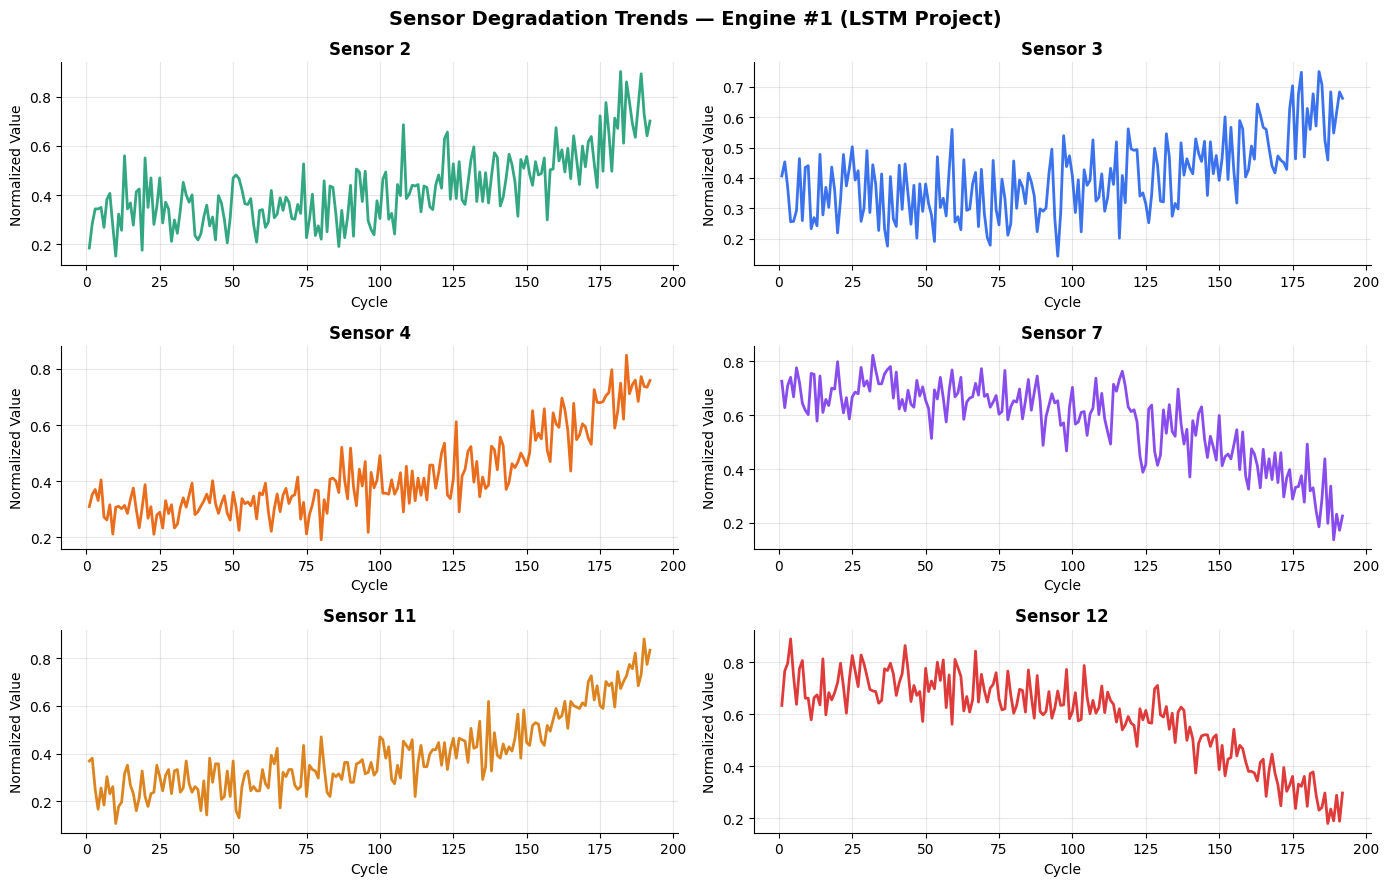

✓ Saved: 1_sensor_trends_lstm.png


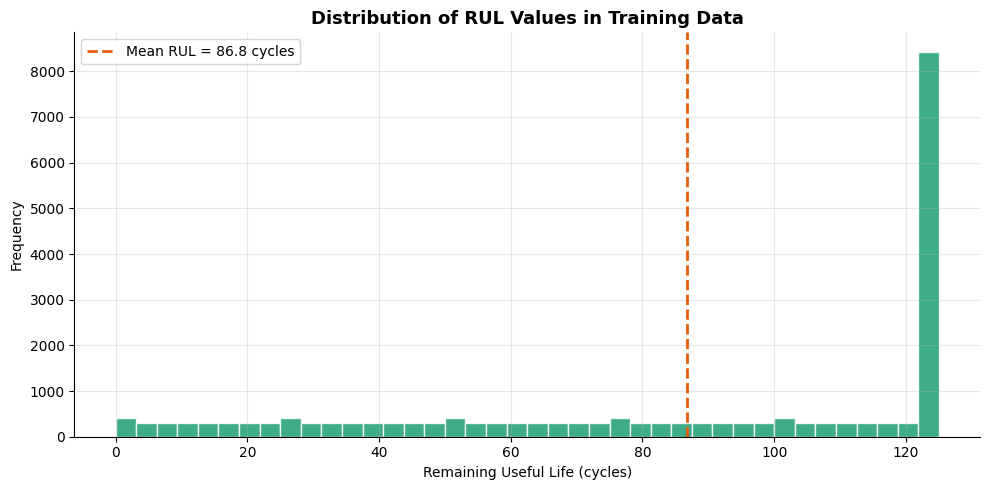

✓ Saved: 2_rul_distribution_lstm.png


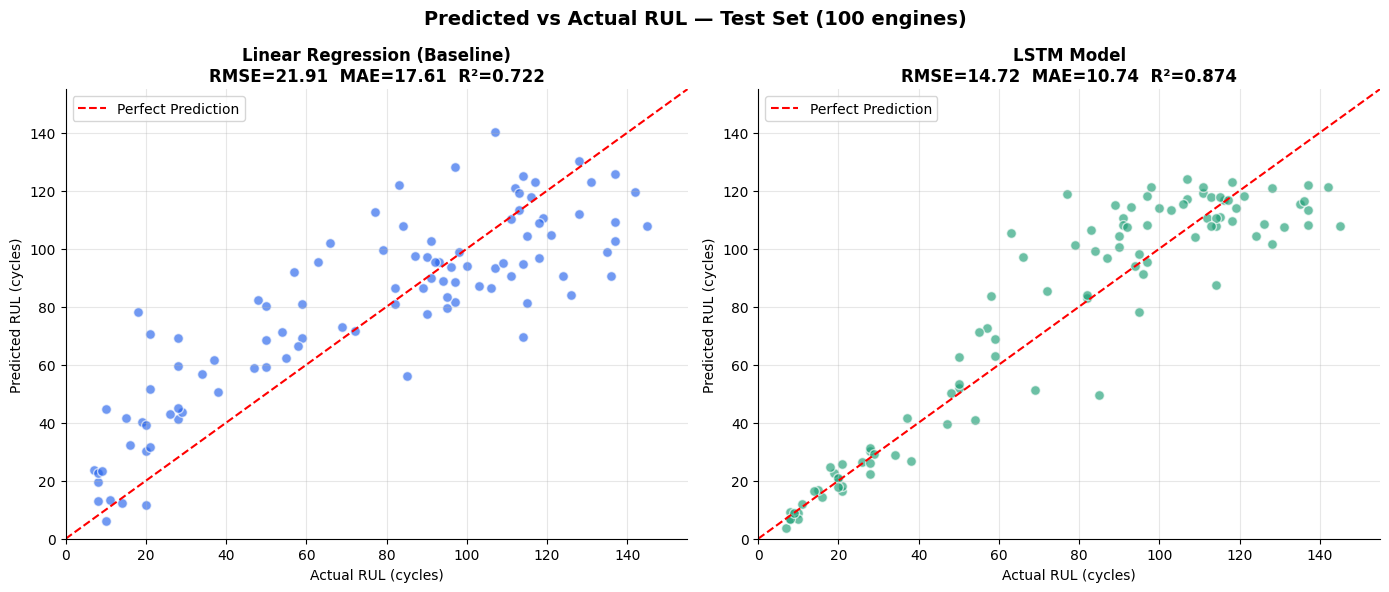

✓ Saved: 3_pred_vs_actual_lstm.png


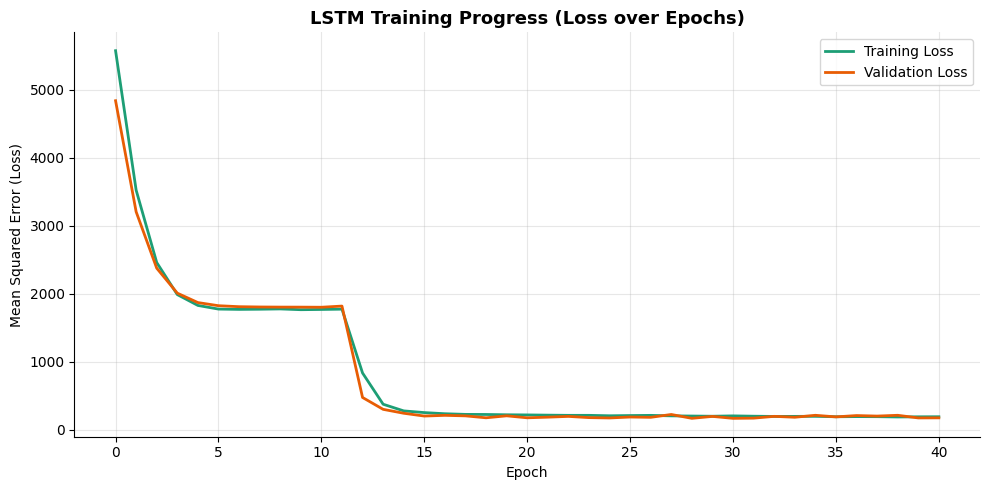

✓ Saved: 4_training_loss_lstm.png


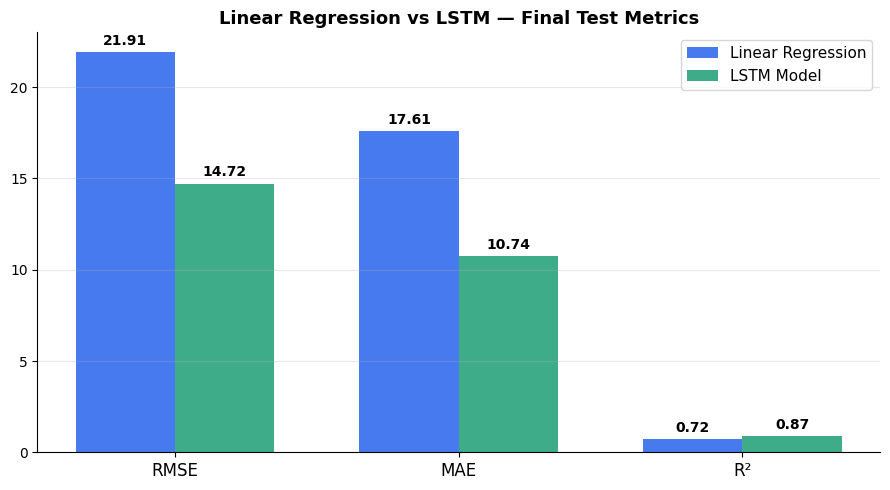

✓ Saved: 5_model_comparison_lstm.png

════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════
1_sensor_trends_lstm.png
2_rul_distribution_lstm.png
3_pred_vs_actual_lstm.png
4_training_loss_lstm.png
5_model_comparison_lstm.png


In [23]:
# 1. Sensor Degradation Trends - Engine #1
SENSORS_TO_PLOT = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12']
COLORS = ['#1D9E75','#2563EB','#E85D04','#7C3AED','#D97706','#DC2626']

engine1 = train_df[train_df['engine_id'] == 1]
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
fig.suptitle('Sensor Degradation Trends — Engine #1 (LSTM Project)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, sensor in enumerate(SENSORS_TO_PLOT):
    if sensor in engine1.columns:
        axes[i].plot(engine1['cycle'], engine1[sensor], color=COLORS[i], linewidth=2, alpha=0.9)
        axes[i].set_title(sensor.replace('_',' ').title(), fontweight='bold')
        axes[i].set_xlabel('Cycle')
        axes[i].set_ylabel('Normalized Value')
        axes[i].grid(alpha=0.3)
        axes[i].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/1_sensor_trends_lstm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 1_sensor_trends_lstm.png")

# 2. RUL Distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_df['RUL'], bins=40, color='#1D9E75', alpha=0.85, edgecolor='white')
ax.axvline(train_df['RUL'].mean(), color='#E85D04', linestyle='--', linewidth=2,
           label=f"Mean RUL = {train_df['RUL'].mean():.1f} cycles")
ax.set_title('Distribution of RUL Values in Training Data', fontsize=13, fontweight='bold')
ax.set_xlabel('Remaining Useful Life (cycles)')
ax.set_ylabel('Frequency')
ax.legend()
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/2_rul_distribution_lstm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 2_rul_distribution_lstm.png")

# 3. Predicted vs Actual RUL (LSTM + Linear Regression)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, res, color, title in zip(axes, [lr_res, lstm_res], ['#2563EB', '#1D9E75'],
                                 ["Linear Regression (Baseline)", "LSTM Model"]):
    ax.scatter(true_rul, res['pred'], alpha=0.65, color=color, s=50, edgecolors='white')
    lim = max(true_rul.max(), res['pred'].max()) + 10
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel('Actual RUL (cycles)')
    ax.set_ylabel('Predicted RUL (cycles)')
    ax.set_title(f"{title}\nRMSE={res['rmse']:.2f}  MAE={res['mae']:.2f}  R²={res['r2']:.3f}",
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Predicted vs Actual RUL — Test Set (100 engines)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/3_pred_vs_actual_lstm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 3_pred_vs_actual_lstm.png")

# 4. Training Loss Curve (Only for LSTM)
if 'history' in globals():
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(history.history['loss'], label='Training Loss', color='#1D9E75', linewidth=2)
    ax.plot(history.history['val_loss'], label='Validation Loss', color='#E85D04', linewidth=2)
    ax.set_title('LSTM Training Progress (Loss over Epochs)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Squared Error (Loss)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('/kaggle/working/4_training_loss_lstm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 4_training_loss_lstm.png")

# 5. Model Comparison Bar Chart
metrics = ['RMSE', 'MAE', 'R²']
lr_vals = [lr_res['rmse'], lr_res['mae'], lr_res['r2']]
lstm_vals = [lstm_res['rmse'], lstm_res['mae'], lstm_res['r2']]

x = np.arange(3)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, lr_vals, width, label='Linear Regression', color='#2563EB', alpha=0.85)
ax.bar(x + width/2, lstm_vals, width, label='LSTM Model', color='#1D9E75', alpha=0.85)

for i, (lv, lsv) in enumerate(zip(lr_vals, lstm_vals)):
    ax.text(i - width/2, lv + 0.4, f'{lv:.2f}', ha='center', fontsize=10, fontweight='bold')
    ax.text(i + width/2, lsv + 0.4, f'{lsv:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_title('Linear Regression vs LSTM — Final Test Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/kaggle/working/5_model_comparison_lstm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 5_model_comparison_lstm.png")

# Final Summary
print("\n" + "═"*60)
print("═"*60)
print("1_sensor_trends_lstm.png")
print("2_rul_distribution_lstm.png")
print("3_pred_vs_actual_lstm.png")
print("4_training_loss_lstm.png")
print("5_model_comparison_lstm.png")

In [24]:
COLUMNS = [
    'engine_id', 'cycle', 'setting1', 'setting2', 'setting3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
    'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'
]

train_df = pd.read_csv('/kaggle/input/datasets/jeevankfibi/pm-rul/train_FD001.txt',
                        sep=r'\s+', header=None, names=COLUMNS)
test_df = pd.read_csv('/kaggle/input/datasets/jeevankfibi/pm-rul/test_FD001.txt',
                        sep=r'\s+', header=None, names=COLUMNS)

In [25]:
DROP_SENSORS = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
train_df = train_df.drop(columns=DROP_SENSORS)
test_df = test_df.drop(columns=DROP_SENSORS)

In [26]:
feature_cols = [c for c in train_df.columns if c not in ['engine_id', 'cycle']]
scaler = MinMaxScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [27]:
RUL_CAP = 125
max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']
train_df = train_df.merge(max_cycle, on='engine_id')
train_df['RUL'] = (train_df['max_cycle'] - train_df['cycle']).clip(upper=RUL_CAP)
train_df.drop(columns=['max_cycle'], inplace=True)

In [28]:
sensor_cols = [c for c in train_df.columns if c.startswith('sensor_')]

In [29]:
healthy_data = train_df[train_df['RUL'] > 100][sensor_cols].values

model_ae = Sequential([
    Dense(32, activation='relu', input_shape=(len(sensor_cols),)),
    Dense(16, activation='relu'),
    Dense(8,  activation='relu'),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(len(sensor_cols), activation='sigmoid')
])

In [30]:
model_ae.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='loss', patience=8, restore_best_weights=True)


In [31]:
history = model_ae.fit(healthy_data, healthy_data, 
                       epochs=60, batch_size=32, 
                       validation_split=0.2, callbacks=[early_stop], 
                       verbose=0)

In [32]:
test_last = test_df.groupby('engine_id').last().reset_index()
X_test_anomaly = test_last[sensor_cols].values

reconstructions = model_ae.predict(X_test_anomaly, verbose=0)
mse = np.mean(np.power(X_test_anomaly - reconstructions, 2), axis=1)

In [33]:
train_recon = model_ae.predict(healthy_data, verbose=0)
train_mse = np.mean(np.power(healthy_data - train_recon, 2), axis=1)
threshold = np.percentile(train_mse, 95)

print(f"📊 Anomaly threshold set at: {threshold:.5f}\n")

📊 Anomaly threshold set at: 0.00441



In [34]:
anomaly_engines = []
print("="*80)
print("ANOMALY DETECTION RESULTS (Last Cycle of Each Test Engine)")
print("="*80)

ANOMALY DETECTION RESULTS (Last Cycle of Each Test Engine)


In [35]:
for i, engine_id in enumerate(test_last['engine_id']):
    score = mse[i]
    if score > threshold:
        anomaly_engines.append(int(engine_id))
        print(f"ANOMALY DETECTED for Engine #{int(engine_id)} ")
        print(f"   Anomaly Score : {score:.5f}  (Threshold = {threshold:.5f})")
        print(f"   Status        :  EARLY FAULT WARNING!")
        
        # Top abnormal sensors
        error_per_sensor = np.abs(X_test_anomaly[i] - reconstructions[i])
        top_idx = np.argsort(error_per_sensor)[-5:]
        print("   Most abnormal sensors:")
        for idx in reversed(top_idx):
            print(f"      → {sensor_cols[idx]:12} error = {error_per_sensor[idx]:.5f}")
        print("-"*70)
    else:
        print(f"Engine #{int(engine_id):3d} : Normal (Score = {score:.5f})")

print(f"\n SUMMARY: {len(anomaly_engines)} out of {len(test_last)} test engines have anomalies.")
if anomaly_engines:
    print(f"   Anomalous Engines: {anomaly_engines}")

Engine #  1 : Normal (Score = 0.00267)
Engine #  2 : Normal (Score = 0.00126)
ANOMALY DETECTED for Engine #3 
   Anomaly Score : 0.00503  (Threshold = 0.00441)
   Status        :  EARLY FAULT WARNING!
   Most abnormal sensors:
      → sensor_15    error = 0.14549
      → sensor_11    error = 0.13845
      → sensor_4     error = 0.10851
      → sensor_20    error = 0.07140
      → sensor_7     error = 0.05706
----------------------------------------------------------------------
ANOMALY DETECTED for Engine #4 
   Anomaly Score : 0.00478  (Threshold = 0.00441)
   Status        :  EARLY FAULT WARNING!
   Most abnormal sensors:
      → sensor_12    error = 0.16890
      → sensor_20    error = 0.13119
      → sensor_4     error = 0.09230
      → sensor_17    error = 0.05906
      → sensor_7     error = 0.05825
----------------------------------------------------------------------
Engine #  5 : Normal (Score = 0.00312)
Engine #  6 : Normal (Score = 0.00117)
Engine #  7 : Normal (Score = 0.00

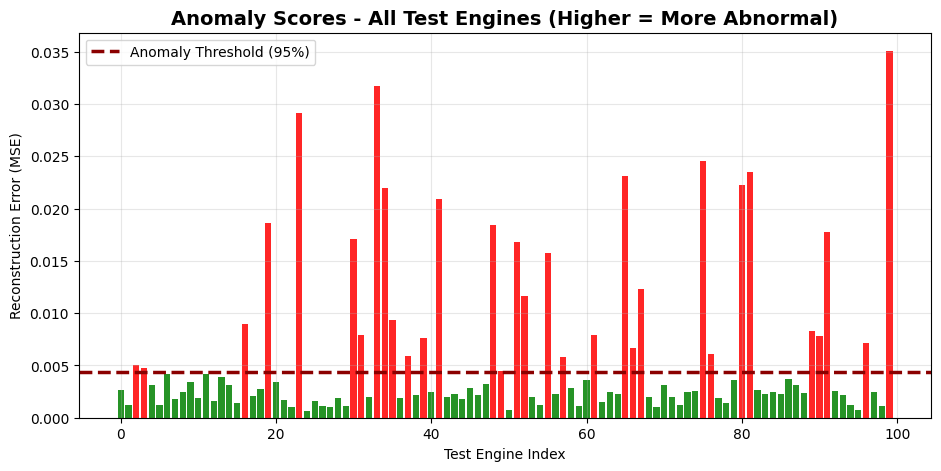

In [36]:
plt.figure(figsize=(11, 5))
colors = ['red' if s > threshold else 'green' for s in mse]
plt.bar(range(len(mse)), mse, color=colors, alpha=0.85)
plt.axhline(y=threshold, color='darkred', linestyle='--', linewidth=2.5, label='Anomaly Threshold (95%)')
plt.title('Anomaly Scores - All Test Engines (Higher = More Abnormal)', fontsize=14, fontweight='bold')
plt.xlabel('Test Engine Index')
plt.ylabel('Reconstruction Error (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('/kaggle/working/anomaly_detection_results.png', dpi=160, bbox_inches='tight')
plt.show()


In [37]:
max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']
train_df = train_df.merge(max_cycle, on='engine_id')
train_df['RUL'] = (train_df['max_cycle'] - train_df['cycle']).clip(upper=125)
train_df.drop(columns=['max_cycle'], inplace=True)

In [38]:
def create_fault_label(rul):
    if rul > 80:
        return 0 
    elif rul > 30:
        return 1  
    else:
        return 2  

train_df['fault_type'] = train_df['RUL'].apply(create_fault_label)

In [39]:
test_last = test_df.groupby('engine_id').last().reset_index()
test_last = test_last.merge(train_df[['engine_id', 'RUL']].groupby('engine_id').last().reset_index(), on='engine_id')
test_last['fault_type'] = test_last['RUL'].apply(create_fault_label)

In [40]:
sensor_cols = [c for c in feature_cols if c.startswith('sensor_')]

X_train = train_df[sensor_cols].values
y_train = train_df['fault_type'].values
X_test = test_last[sensor_cols].values
y_test = test_last['fault_type'].values

In [41]:
print(f"Created 3 fault classes (0=Functioning Properly, 1=Early, 2=Critical)")

Created 3 fault classes (0=Functioning Properly, 1=Early, 2=Critical)


In [42]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
print(" Fault Classifier (Random Forest) trained successfully!\n")

 Fault Classifier (Random Forest) trained successfully!



In [43]:
y_pred = rf_clf.predict(X_test)

print("="*80)
print("FAULT CLASSIFICATION RESULTS (Test Engines - Last Cycle)")
print("="*80)

fault_names = {0: "Functioning Properly", 1: "Early Degradation", 2: "Critical Failure"}

FAULT CLASSIFICATION RESULTS (Test Engines - Last Cycle)


In [44]:
for i, engine_id in enumerate(test_last['engine_id']):
    true_class = y_test[i]
    pred_class = y_pred[i]
    prob = np.max(rf_clf.predict_proba(X_test[i:i+1]))
    
    if pred_class == 2:
        print(f"CRITICAL FAULT for Engine #{int(engine_id)}")
        print(f"   Predicted Fault : {fault_names[pred_class]}")
        print(f"   Confidence      : {prob:.1%}")
        print(f"   Action          : Immediate maintenance recommended!")
    elif pred_class == 1:
        print(f"WARNING for Engine #{int(engine_id)}")
        print(f"   Predicted Fault : {fault_names[pred_class]}")
        print(f"   Confidence      : {prob:.1%}")
    else:
        print(f"Engine #{int(engine_id):3d} : {fault_names[pred_class]}")
    print("-"*70)

Engine #  1 : Functioning Properly
----------------------------------------------------------------------
Engine #  2 : Functioning Properly
----------------------------------------------------------------------
WARNING for Engine #3
   Predicted Fault : Early Degradation
   Confidence      : 61.1%
----------------------------------------------------------------------
Engine #  4 : Functioning Properly
----------------------------------------------------------------------
Engine #  5 : Functioning Properly
----------------------------------------------------------------------
Engine #  6 : Functioning Properly
----------------------------------------------------------------------
Engine #  7 : Functioning Properly
----------------------------------------------------------------------
Engine #  8 : Functioning Properly
----------------------------------------------------------------------
Engine #  9 : Functioning Properly
----------------------------------------------------------------

In [45]:
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=list(fault_names.values())))


📊 Classification Report:
                      precision    recall  f1-score   support

Functioning Properly       0.00      0.00      0.00         0
   Early Degradation       0.00      0.00      0.00         0
    Critical Failure       1.00      0.17      0.29       100

            accuracy                           0.17       100
           macro avg       0.33      0.06      0.10       100
        weighted avg       1.00      0.17      0.29       100



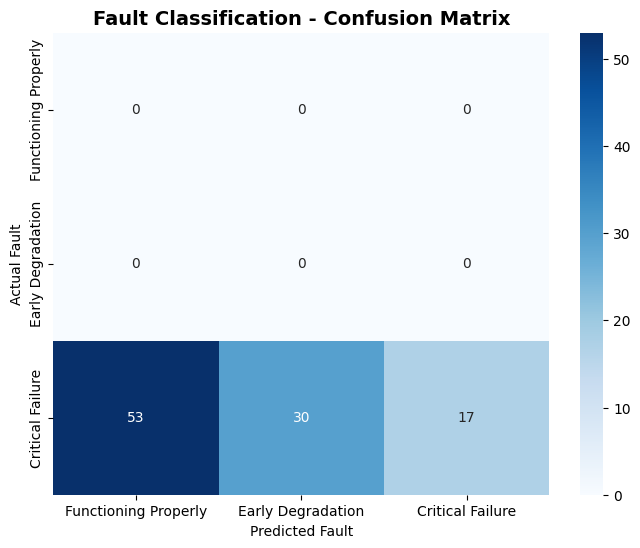

In [46]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(fault_names.values()), 
            yticklabels=list(fault_names.values()))
plt.title('Fault Classification - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Fault')
plt.ylabel('Actual Fault')
plt.savefig('/kaggle/working/fault_classification_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()